In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset, concatenate_datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)
from scipy.spatial.distance import cdist
from torch.utils.data import Dataset, DataLoader
from transformers import (Wav2Vec2Processor, Wav2Vec2Model)

In [ ]:
dataset = load_dataset("capa2000/binary-classifier-birdnet")

full_dataset = concatenate_datasets([dataset["train"], dataset["test"]])

split_dataset = full_dataset.train_test_split(test_size=0.2, seed=42, shuffle=True)

train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 320
Test size: 80


In [ ]:
all_labels = sorted(list(set(full_dataset["nombreCientifico"])))

label_to_id = {label: idx for idx, label in enumerate(all_labels)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

num_classes = len(label_to_id)

print(f"Number of classes: {num_classes}")
print(all_labels[:5])

Number of classes: 2
['Accipiter striatus', 'Acropternis orthonyx']


In [ ]:
def extract_mfcc_features(audio, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    features = np.concatenate([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.max(mfcc, axis=1),
        np.min(mfcc, axis=1)
    ])
    return features

def build_mfcc_dataset(dataset):
    X = []
    y = []

    for item in dataset:
        audio = item["audio"]["array"]
        sr = item["audio"]["sampling_rate"]
        features = extract_mfcc_features(audio, sr)
        X.append(features)
        y.append(label_to_id[item["nombreCientifico"]])
    return np.array(X), np.array(y)

X_train_mfcc, y_train = build_mfcc_dataset(train_dataset)
X_test_mfcc, y_test = build_mfcc_dataset(test_dataset)

print(X_train_mfcc.shape)
print(X_test_mfcc.shape)

(320, 52)
(80, 52)


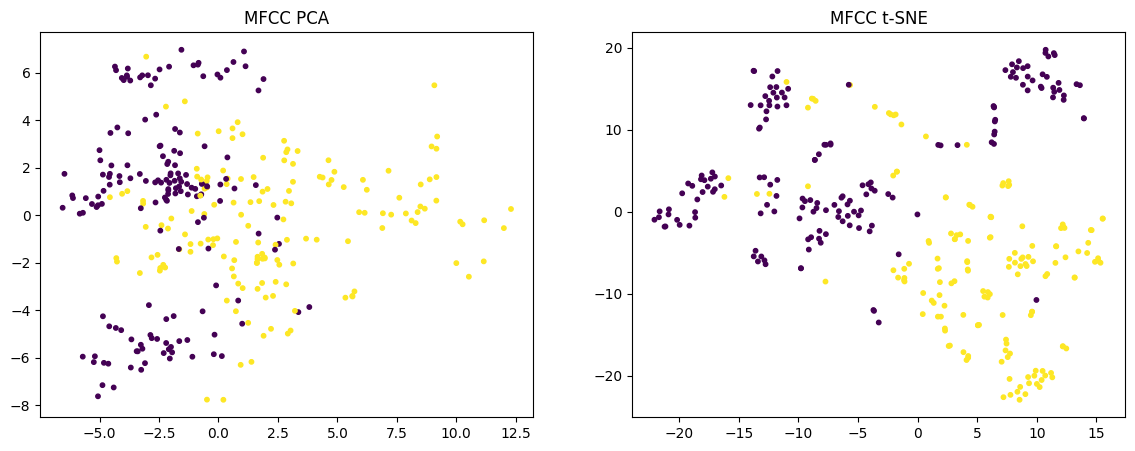

In [ ]:
def visualize_features(X, y, title):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    sample_size = min(500, len(X_scaled))
    indices = np.random.choice(len(X_scaled), sample_size, replace=False)

    X_sample = X_scaled[indices]
    y_sample = y[indices]
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(X_sample)

    _, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, s=10)
    axes[0].set_title(f"{title} PCA")
    axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, s=10)
    axes[1].set_title(f"{title} t-SNE")
    plt.show()

visualize_features(X_train_mfcc, y_train, "MFCC")

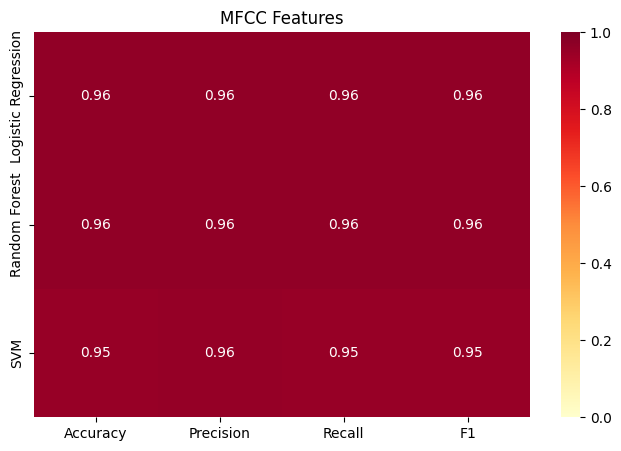

In [ ]:
def evaluate_models(X_train, X_test, y_train, y_test, title):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(n_estimators=100),
        "SVM": SVC()
    }

    results = {}

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        results[name] = {
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, average="weighted"),
            "Recall": recall_score(y_test, preds, average="weighted"),
            "F1": f1_score(y_test, preds, average="weighted")
        }

    results_df = pd.DataFrame(results).T
    plt.figure(figsize=(8, 5))
    sns.heatmap(results_df, annot=True, cmap="YlOrRd", vmin=0, vmax=1)
    plt.title(title)
    plt.show()
    return results_df

results_mfcc = evaluate_models(X_train_mfcc, X_test_mfcc, y_train, y_test, "MFCC Features")

In [10]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
model_name = "facebook/wav2vec2-base"
processor = Wav2Vec2Processor.from_pretrained(model_name)
wav2vec_model = Wav2Vec2Model.from_pretrained(model_name)
wav2vec_model.to(device)
wav2vec_model.eval()

print(device)

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 72731.60it/s]
[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


mps


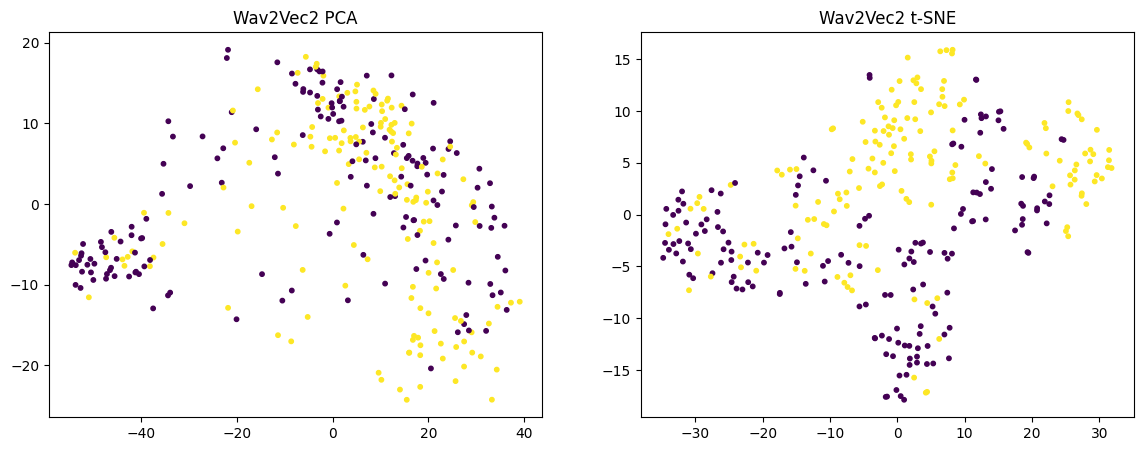

In [ ]:
def extract_wav2vec_features(audio, sr):
    target_sr = 16000
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
    inputs = processor(audio, sampling_rate=target_sr, return_tensors="pt")
    inputs = { k: v.to(device) for k, v in inputs.items() }
    with torch.no_grad():
        outputs = wav2vec_model(**inputs)
    hidden = outputs.last_hidden_state[0].cpu().numpy()
    features = np.concatenate([
        hidden.mean(axis=0),
        hidden.std(axis=0)
    ])
    return features

def build_wav2vec_dataset(dataset):
    X = []
    y = []
    for item in dataset:
        audio = item["audio"]["array"]
        sr = item["audio"]["sampling_rate"]
        features = extract_wav2vec_features(audio, sr)
        X.append(features)
        y.append(label_to_id[item["nombreCientifico"]])
    return np.array(X), np.array(y)

X_train_wav2vec, y_train_wav2vec = build_wav2vec_dataset(train_dataset)
X_test_wav2vec, y_test_wav2vec = build_wav2vec_dataset(test_dataset)
visualize_features(X_train_wav2vec, y_train_wav2vec, "Wav2Vec2")

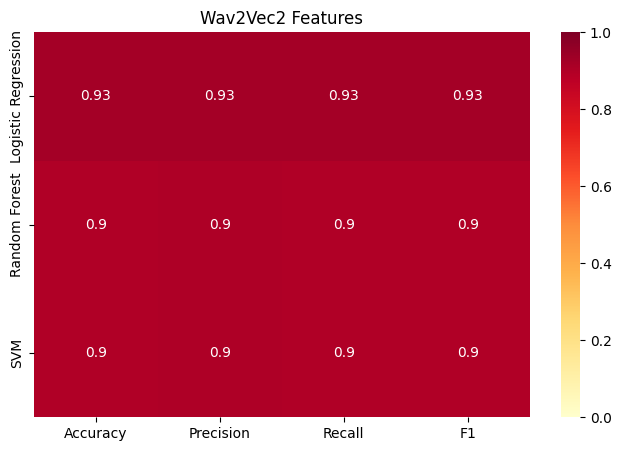

In [12]:
results_wav2vec = evaluate_models(
    X_train_wav2vec,
    X_test_wav2vec,
    y_train_wav2vec,
    y_test_wav2vec,
    "Wav2Vec2 Features"
)

In [ ]:
class AudioDataset(Dataset):

    def __init__(self, dataset, processor, label_to_id, max_length=160000):
        self.dataset = dataset
        self.processor = processor
        self.label_to_id = label_to_id
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        audio = item["audio"]["array"]
        sr = item["audio"]["sampling_rate"]
        if sr != 16000:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)

        if len(audio) > self.max_length:
            audio = audio[:self.max_length]
        else:
            audio = np.pad(audio, (0, self.max_length - len(audio)))

        inputs = processor(
            audio,
            sampling_rate=16000,
            return_tensors="pt"
        )

        return {
            "input_values": inputs.input_values.squeeze(0),
            "label": torch.tensor(self.label_to_id[item["nombreCientifico"]])
        }
    
class Wav2VecClassifier(nn.Module):
    def __init__(self, wav2vec_model, num_classes, freeze_backbone=True):
        super().__init__()
        self.wav2vec2 = wav2vec_model
        if freeze_backbone:
            for param in self.wav2vec2.parameters():
                param.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_values):
        outputs = self.wav2vec2(input_values)
        features = outputs.last_hidden_state.mean(dim=1)
        logits = self.classifier(features)
        return logits
    
train_dl = DataLoader(AudioDataset(train_dataset, processor, label_to_id), batch_size=8, shuffle=True)
test_dl = DataLoader(AudioDataset(test_dataset, processor, label_to_id), batch_size=8, shuffle=False)

In [ ]:
def train_model(model, train_loader, test_loader, epochs=3, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    model.to(device)
    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            x = batch["input_values"].to(device)
            y = batch["label"].to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
        model.eval()
        preds_all = []
        labels_all = []
        with torch.no_grad():
            for batch in test_loader:
                x = batch["input_values"].to(device)
                logits = model(x)
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                preds_all.extend(preds)
                labels_all.extend(batch["label"].numpy())
        f1 = f1_score(labels_all, preds_all, average="weighted")
        print(f"Epoch {epoch+1}: F1 = {f1:.4f}")
    return model

frozen_model = Wav2VecClassifier(Wav2Vec2Model.from_pretrained(model_name), num_classes, freeze_backbone=True)
frozen_model = train_model(frozen_model, train_dl, test_dl, epochs=3, lr=1e-3)

Epoch 1: F1 = 0.7113
Epoch 2: F1 = 0.7546
Epoch 3: F1 = 0.7546


In [15]:
finetuned_model = Wav2VecClassifier(Wav2Vec2Model.from_pretrained(model_name), num_classes, freeze_backbone=False)
finetuned_model = train_model(finetuned_model, train_dl, test_dl, epochs=3, lr=1e-5)

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 71044.24it/s]
[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1: F1 = 0.7404
Epoch 2: F1 = 0.8873
Epoch 3: F1 = 0.9626


In [20]:
def extract_finetuned_features(model, dataset, processor):
    model.eval()
    X = []
    y = []
    for item in dataset:
        audio = item["audio"]["array"]
        sr = item["audio"]["sampling_rate"]
        if sr != 16000:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
        input_values = inputs.input_values.to(device)
        with torch.no_grad():
            outputs = model.wav2vec2(input_values)
            hidden = (outputs.last_hidden_state[0].cpu().numpy())
        features = np.concatenate([
            hidden.mean(axis=0),
            hidden.std(axis=0)
        ])
        X.append(features)
        y.append(label_to_id[item["nombreCientifico"]])
    return np.array(X), np.array(y)

X_train_finetuned, y_train_finetuned = (extract_finetuned_features(finetuned_model, train_dataset, processor))
X_test_finetuned, y_test_finetuned = (extract_finetuned_features(finetuned_model, test_dataset, processor))

print(X_train_finetuned.shape)
print(X_test_finetuned.shape)

(320, 1536)
(80, 1536)


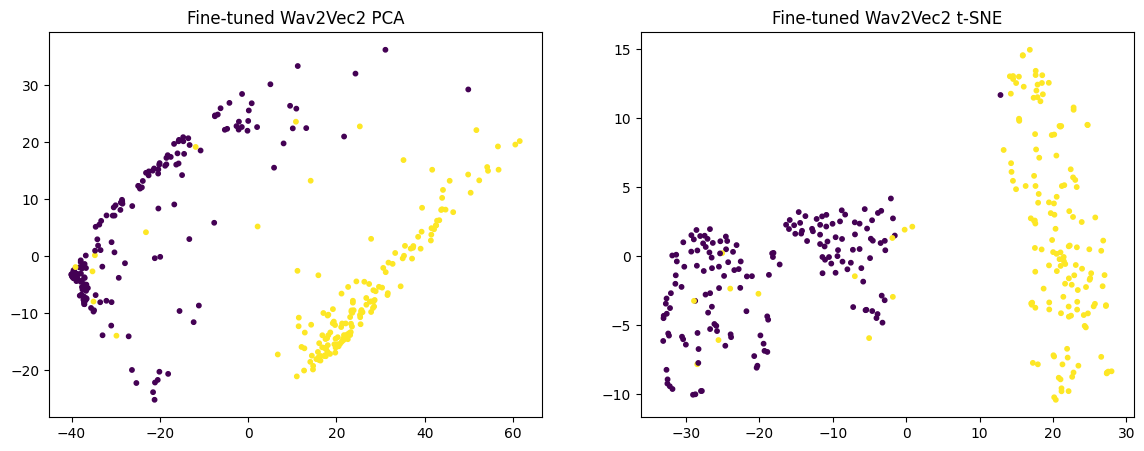

In [21]:
visualize_features(
    X_train_finetuned,
    y_train_finetuned,
    "Fine-tuned Wav2Vec2"
)

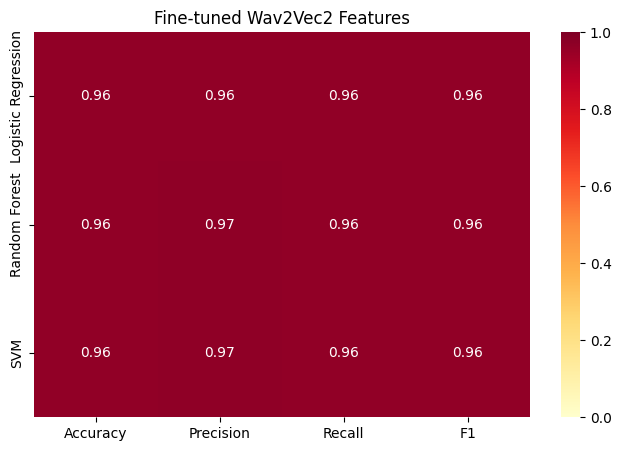

In [23]:
results_finetuned = evaluate_models(
    X_train_finetuned,
    X_test_finetuned,
    y_train_finetuned,
    y_test_finetuned,
    "Fine-tuned Wav2Vec2 Features"
)

In [25]:
summary = pd.DataFrame({
    "MFCC": results_mfcc["F1"],
    "Wav2Vec2": results_wav2vec["F1"],
    "Finetuned Wav2Vec2": results_finetuned["F1"]
})

print(summary)

                         MFCC  Wav2Vec2  Finetuned Wav2Vec2
Logistic Regression  0.962541  0.925000            0.962447
Random Forest        0.962541  0.900251            0.962588
SVM                  0.950125  0.900251            0.962588


In [26]:
distances = cdist(X_test_finetuned, X_test_finetuned, metric="euclidean")
np.fill_diagonal(distances, np.inf)
closest_pair = np.unravel_index(np.argmin(distances), distances.shape)

temp = distances.copy()
temp[temp == np.inf] = -np.inf

farthest_pair = np.unravel_index(np.argmax(temp), temp.shape)

print("Closest:", closest_pair)
print("Farthest:", farthest_pair)

Closest: (np.int64(39), np.int64(54))
Farthest: (np.int64(2), np.int64(41))


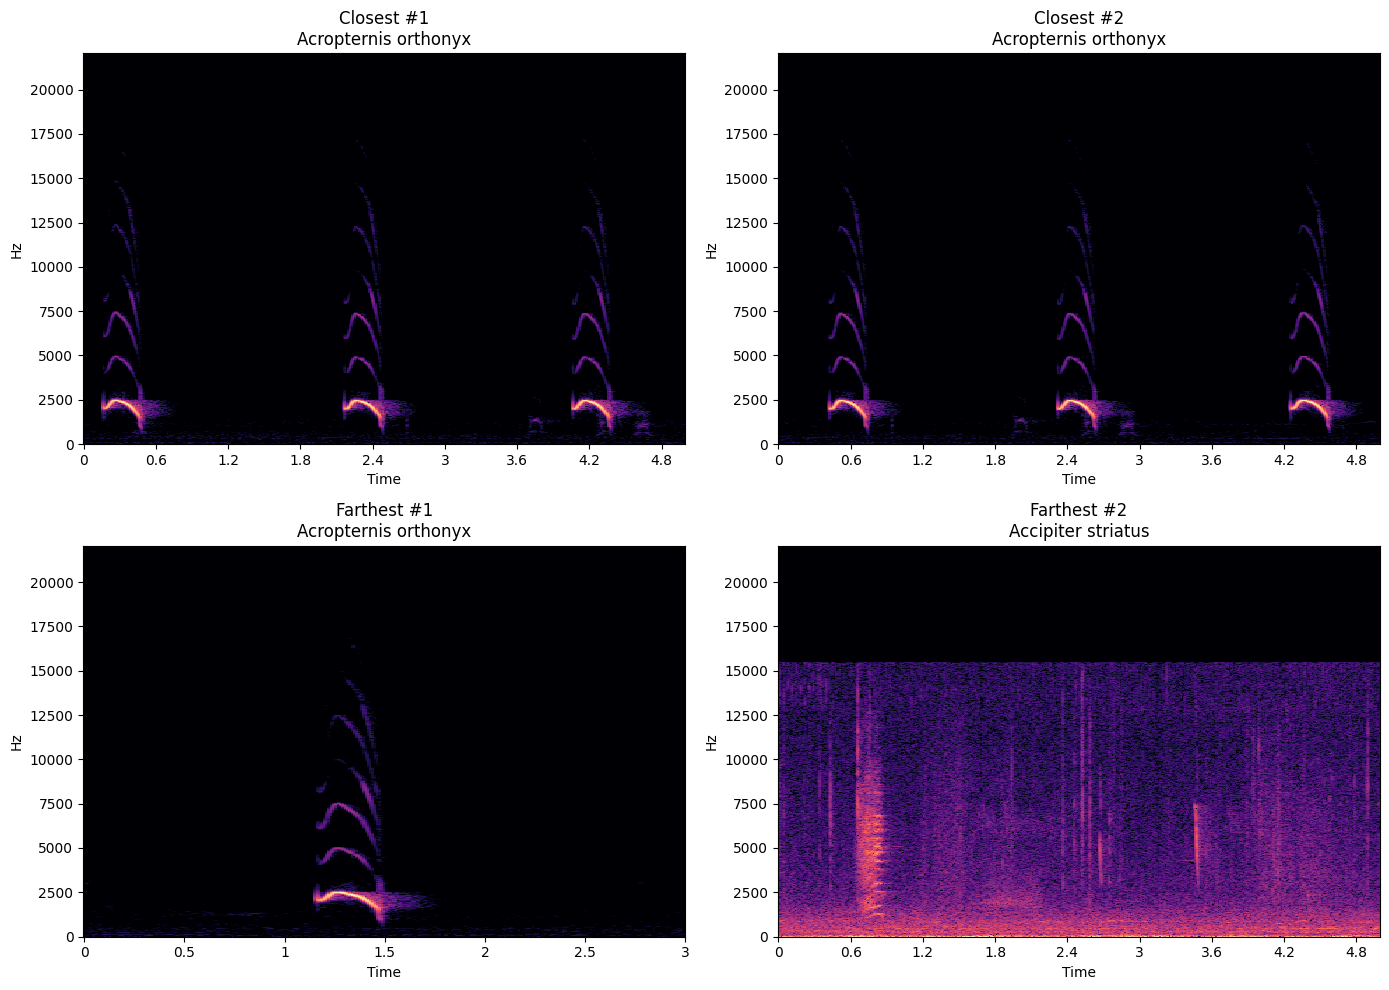

In [27]:
def plot_spectrogram(audio, sr, title, ax):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz", ax=ax)
    ax.set_title(title)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pairs = [closest_pair[0], closest_pair[1], farthest_pair[0], farthest_pair[1]]
titles = ["Closest #1", "Closest #2", "Farthest #1", "Farthest #2"]

for ax, idx, title in zip(axes.flatten(), pairs, titles):
    audio = test_dataset[idx]["audio"]["array"]
    sr = test_dataset[idx]["audio"]["sampling_rate"]
    label = id_to_label[y_test[idx]]
    plot_spectrogram(audio, sr, f"{title}\n{label}", ax)

plt.tight_layout()
plt.show()